In [ ]:
import re
import os
import random
from glob import glob
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torchview import draw_graph
from warnings import filterwarnings
filterwarnings("ignore")

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


set_seed()

### Формирование датасета

Источники данных
1. https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/ OMNI2 Dataset
2. https://cosray.unibe.ch/data/nm/data/ Swiss Neutron Monitor Data (Hourly Values)
3. https://cosmicrays.oulu.fi/ Real-time Oulu NM count rate

In [4]:
data_path = "../data/row/omni/"
file_pattern = os.path.join(data_path, "omni2_*.dat.txt")
file_list = glob(file_pattern)
file_list.sort()

In [5]:
fill_values = {
    # Группа 1: Солнечный ветер и ММП
    'B_Magnitude_Avg': 999.9,      
    'Bx_GSE': 999.9,               
    'By_GSM': 999.9,              
    'Bz_GSM': 999.9,               
    'T_proton': 9999999.0,         
    'Np_density': 999.9,           
    'V_plasma': 9999.0,           
    'P_dyn': 99.99,               
    # Группа 3: Геомагнитные индексы
    'Kp': 99,                     
    'Dst': 99999,                 
    'AE': 9999,                   
    'ap': 999,                    
    'AL': 99999,                 
    'AU': 99999,                
}
required_omni_columns = ["Year", "Decimal Day", "Hour"]
required_omni_columns.extend(list(fill_values.keys()))

In [6]:
df_list = []

for file in file_list:
    df_temp = pd.read_csv(file, header=None, sep="\\s+")
    df_temp.columns = [
        "Year", "Decimal Day", "Hour", "Bartels", "IMF_s/c_ID", "Plasma_s/c_ID",
        "N_IMF_points", "N_Plasma_points", "B_Magnitude_Avg", "B_Vector_Mag",
        "B_Lat_GSE", "B_Long_GSE", "Bx_GSE", "By_GSE", "Bz_GSE", "By_GSM",
        "Bz_GSM", "sigma_B_Mag", "sigma_B_Vector", "sigma_Bx", "sigma_By",
        "sigma_Bz", "T_proton", "Np_density", "V_plasma", "V_Long_GSE",
        "V_Lat_GSE", "Na/Np", "P_dyn", "sigma_T", "sigma_N", "sigma_V",
        "sigma_phi_V", "sigma_theta_V", "sigma_Na/Np", "E_field", "Plasma_beta",
        "Alfven_Mach", "Kp", "R_sunspot", "Dst", "AE", "P_flux_>1MeV",
        "P_flux_>2MeV", "P_flux_>4MeV", "P_flux_>10MeV", "P_flux_>30MeV",
        "P_flux_>60MeV", "Flag", "ap", "f10.7", "PC(N)", "AL", "AU", "Mach_num"
    ]
    
    df_list.append(df_temp[required_omni_columns])

In [7]:
full_omni_dataset = pd.concat(df_list, ignore_index=True)
full_omni_dataset['datetime'] = pd.to_datetime(
    full_omni_dataset['Year'].astype(str) + '-' +
    full_omni_dataset['Decimal Day'].astype(str) +
    ' ' +
    full_omni_dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
full_omni_dataset = full_omni_dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in full_omni_dataset.columns if col != 'datetime']
full_omni_dataset = full_omni_dataset[cols]
full_omni_dataset.head()

,datetime,B_Magnitude_Avg,Bx_GSE,By_GSM,Bz_GSM,T_proton,Np_density,V_plasma,P_dyn,Kp,Dst,AE,ap,AL,AU
0,1995-01-01 00:00:00,4.0,-0.6,3.6,-1.2,15816.0,16.3,315.0,2.87,10,-2,32,4,-6,25
1,1995-01-01 01:00:00,3.0,-0.9,2.6,-0.7,15601.0,18.8,315.0,3.28,10,3,38,4,-11,26
2,1995-01-01 02:00:00,3.2,0.5,1.8,0.0,20703.0,19.3,320.0,3.46,10,6,34,4,-12,20
3,1995-01-01 03:00:00,4.3,-3.2,2.4,0.7,25094.0,16.4,317.0,2.90,0,5,36,0,-11,24
4,1995-01-01 04:00:00,4.8,-4.3,2.1,0.5,25604.0,14.5,313.0,2.51,0,3,31,0,-10,19


<Axes: >

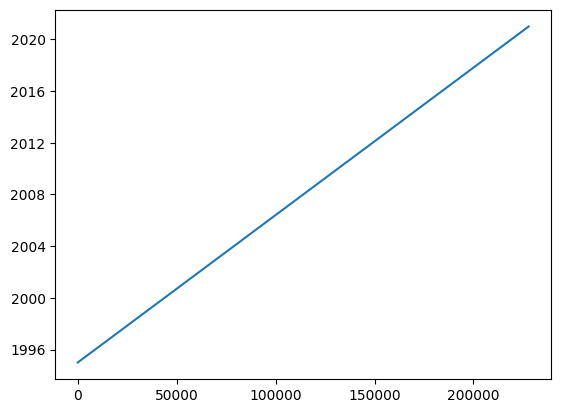

In [7]:
full_omni_dataset["datetime"].plot()

In [8]:
for col in full_omni_dataset.columns:  # type: ignore
    if col not in fill_values:
        continue
    else:
        full_omni_dataset[col] = full_omni_dataset[col].replace(fill_values[col], np.nan)

nan_counter = full_omni_dataset.isna().sum()

```
Kp was treated specially.  After determining daily or 27-averages from 
basic values such as 10 (1), 13 (1+), 17 (2-), 20 (2), the average was 
rounded to the nearest "standard value" of Kp (i.e., 10, 13, 17, 20, ...).  
For cases where the average was exactly in the middle between standard 
values (e.g., 15), the lower standard value (13 in this case) was used.
```

In [9]:
full_omni_dataset['Kp'] = full_omni_dataset['Kp'] / 10.0
full_omni_dataset.head()

,datetime,B_Magnitude_Avg,Bx_GSE,By_GSM,Bz_GSM,T_proton,Np_density,V_plasma,P_dyn,Kp,Dst,AE,ap,AL,AU
0,1995-01-01 00:00:00,4.0,-0.6,3.6,-1.2,15816.0,16.3,315.0,2.87,1.0,-2,32,4,-6,25
1,1995-01-01 01:00:00,3.0,-0.9,2.6,-0.7,15601.0,18.8,315.0,3.28,1.0,3,38,4,-11,26
2,1995-01-01 02:00:00,3.2,0.5,1.8,0.0,20703.0,19.3,320.0,3.46,1.0,6,34,4,-12,20
3,1995-01-01 03:00:00,4.3,-3.2,2.4,0.7,25094.0,16.4,317.0,2.90,0.0,5,36,0,-11,24
4,1995-01-01 04:00:00,4.8,-4.3,2.1,0.5,25604.0,14.5,313.0,2.51,0.0,3,31,0,-10,19


### JUNG data

In [10]:
out = Path("../data/row/jung/")
out.mkdir(exist_ok=True)

In [ ]:
for year in range(1995, 2021):
    yy = str(year)[2:] 

    for month in range(1, 13):
        if year <= 2010:
            detector_folder = "nm64"
        else:
            detector_folder = "NM64"
        
        url = f"https://cosray.unibe.ch/data/nm/data/{year}/{detector_folder}/jn{yy}{month:02d}.txt"
        
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            fn = out / f"jn{yy}{month:02d}.txt"
            fn.write_bytes(r.content)
            print("OK", fn.name)
        else:
            print(f"MISS: {url} - Status: {r.status_code}")

In [11]:
rows = []

for file in sorted(out.glob("*.txt")):

    with open(file, "r", encoding="latin1", errors="ignore") as f:

        for line in f:
            if not re.match(r"^\d{4}\s+\d+", line):
                continue

            parts = line.split()

            year  = int(parts[0])
            month = int(parts[1])
            day   = int(parts[2])

            # HHMM как число (ВАЖНО)
            hhmm = int(parts[3])

            corr_raw = parts[-1]
            corr_raw = corr_raw.replace("-", "")
            corr_raw = corr_raw.replace("/", "")

            # иногда бывают пустые/битые значения
            try:
                corr = float(corr_raw)
            except Exception:
                continue

            hour = hhmm // 100
            minute = hhmm % 100

            if hour == 24:
                dt = pd.Timestamp(year, month, day) + pd.Timedelta(days=1)
            else:
                dt = pd.Timestamp(year, month, day, hour, minute)

            rows.append([dt, corr])


full_jung_dataset = pd.DataFrame(rows, columns=["datetime", "JUNG"])

full_jung_dataset = (
    full_jung_dataset
    .drop_duplicates("datetime")
    .sort_values("datetime")
    .set_index("datetime")
)

In [12]:
full_jung_dataset = full_jung_dataset.reset_index()
full_jung_dataset = full_jung_dataset[full_jung_dataset['datetime'].dt.year < 2021]
if 'index' in full_jung_dataset.columns:
    full_jung_dataset = full_jung_dataset.drop(columns=['index'])
full_jung_dataset = full_jung_dataset.sort_values('datetime')
full_jung_dataset = full_jung_dataset.reset_index(drop=True)
full_jung_dataset.head()

,datetime,JUNG
0,1995-01-01 01:00:00,6733.4
1,1995-01-01 02:00:00,6715.3
2,1995-01-01 03:00:00,6699.0
3,1995-01-01 04:00:00,6736.2
4,1995-01-01 05:00:00,6715.7


In [14]:
# copy = full_jung_dataset.copy()
# copy.loc[copy["JUNG"] < 10, "JUNG"] = np.nan
# plt.plot(copy["datetime"], copy["JUNG"])

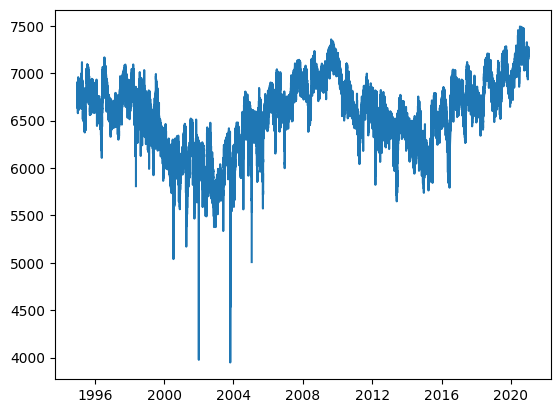

In [16]:
full_jung_dataset.loc[full_jung_dataset["JUNG"] < 10, "JUNG"] = np.nan
plt.plot(full_jung_dataset["datetime"], full_jung_dataset["JUNG"])

In [17]:
jung_dates = set(full_jung_dataset['datetime'])
omni_dates = set(full_omni_dataset['datetime'])
missing_in_jung = omni_dates - jung_dates
print(f"Даты в OMNI, отсутствующие в JUNG: {len(missing_in_jung)}")
print(sorted(missing_in_jung)[:10]) 
missing_in_omni = jung_dates - omni_dates
print(f"\nДаты в JUNG, отсутствующие в OMNI: {len(missing_in_omni)}")
print(sorted(missing_in_omni)[:10])

Даты в OMNI, отсутствующие в JUNG: 0
[]

Даты в JUNG, отсутствующие в OMNI: 0
[]


In [19]:
full_jung_dataset = (
    full_jung_dataset
    .set_index('datetime')
    .reindex(full_omni_dataset['datetime'])
    .reset_index()
    .rename(columns={'index': 'datetime', 'JUNG': 'JUNG'})
)
full_jung_dataset.head()

,datetime,JUNG
0,1995-01-01 00:00:00,NaN
1,1995-01-01 01:00:00,6733.4
2,1995-01-01 02:00:00,6715.3
3,1995-01-01 03:00:00,6699.0
4,1995-01-01 04:00:00,6736.2


In [20]:
full_jung_dataset.to_csv("jung.csv", header=False)

### OULU data

In [20]:
full_oulu_dataset = pd.read_csv("../data/row/oulu/OULU_1995_01_01 _00_00_2020_12_31 _23_30.csv")
full_oulu_dataset["Timestamp"] = pd.to_datetime(full_oulu_dataset["Timestamp"])
full_oulu_dataset["Timestamp"] = full_oulu_dataset["Timestamp"].dt.tz_localize(None)
full_oulu_dataset.head()

,Timestamp,FractionalDate,UncorrectedCountRate[cts/min],CorrectedCountRate[cts/min],Pressure[mbar]
0,1995-01-01 00:00:00,1995.000000,7239,6371,981.19
1,1995-01-01 01:00:00,1995.000114,7212,6356,981.39
2,1995-01-01 02:00:00,1995.000228,7182,6339,981.59
3,1995-01-01 03:00:00,1995.000342,7197,6355,981.65
4,1995-01-01 04:00:00,1995.000457,7176,6334,981.60


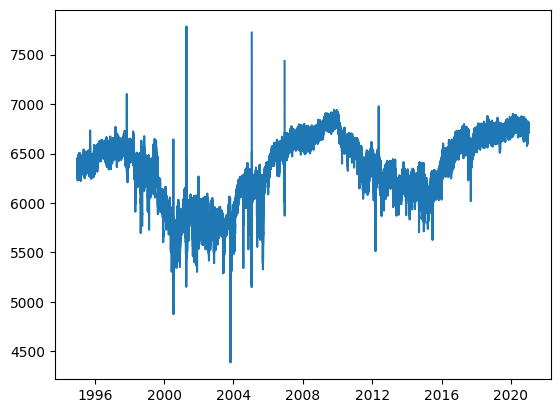

In [23]:
full_oulu_dataset.loc[full_oulu_dataset["CorrectedCountRate[cts/min]"] < 10, "CorrectedCountRate[cts/min]"] = np.nan
full_oulu_dataset.loc[full_oulu_dataset["CorrectedCountRate[cts/min]"] > 8000, "CorrectedCountRate[cts/min]"] = np.nan
plt.plot(full_oulu_dataset["Timestamp"], full_oulu_dataset["CorrectedCountRate[cts/min]"])

In [24]:
full_oulu_dataset["Timestamp"].max(), full_omni_dataset["datetime"].max()

(Timestamp('2020-12-31 22:00:00'), Timestamp('2020-12-31 23:00:00'))

In [25]:
full_oulu_dataset = (
    full_oulu_dataset
    .set_index('Timestamp')
    .reindex(full_omni_dataset['datetime'])
    .reset_index()
    .rename(columns={'index': 'datetime'})
)
full_oulu_dataset.head()

,datetime,FractionalDate,UncorrectedCountRate[cts/min],CorrectedCountRate[cts/min],Pressure[mbar]
0,1995-01-01 00:00:00,1995.000000,7239.0,6371.0,981.19
1,1995-01-01 01:00:00,1995.000114,7212.0,6356.0,981.39
2,1995-01-01 02:00:00,1995.000228,7182.0,6339.0,981.59
3,1995-01-01 03:00:00,1995.000342,7197.0,6355.0,981.65
4,1995-01-01 04:00:00,1995.000457,7176.0,6334.0,981.60


In [26]:
len(full_oulu_dataset) == len(full_jung_dataset) == len(full_omni_dataset)

True

### Финальная сборка датасета

In [27]:
oulu = full_oulu_dataset[['datetime', 'CorrectedCountRate[cts/min]']].copy()
oulu.columns = ['datetime', 'OULU_flux']

jung = full_jung_dataset[['datetime', 'JUNG']].copy()
jung.columns = ['datetime', 'JUNG_flux']

df = pd.merge(full_omni_dataset, oulu, on='datetime', how='inner')
df = pd.merge(df, jung, on='datetime', how='inner')
df = df.sort_values('datetime')

```math
I_{\text{corrected}} = I_{\text{uncorrected}} \cdot \exp\left(k \cdot \frac{P_0 - P}{10}\right)
```

```math
\text{MA\_24\_OULU}(t) = \frac{1}{24} \sum_{i=1}^{24} \text{OULU}(t - i)
```

```math
\text{MA\_24\_JUNG}(t) = \frac{1}{24} \sum_{i=1}^{24} \text{JUNG}(t - i)
```

In [28]:
df['OULU_MA_24'] = df['OULU_flux'].shift(1).rolling(window=24, min_periods=1).mean()
df['JUNG_MA_24'] = df['JUNG_flux'].shift(1).rolling(window=24, min_periods=1).mean()

```math
\text{Relative-difference} = 2 \cdot \frac{\text{OULU} - \text{JUNG}}{\text{OULU} + \text{JUNG}}
```

In [29]:
eps = 1e-6
df['Inter_Station_RelDiff'] = 2 * (df['OULU_flux'] - df['JUNG_flux']) / (df['OULU_flux'] + df['JUNG_flux'] + eps)

In [30]:
final_features = [
    "datetime",
    # Солнечный ветер и ММП (8 фич)
    'Bx_GSE',           # Bx
    'By_GSM',           # By  
    'Bz_GSM',           # Bz
    'B_Magnitude_Avg',  # Scalar B
    'Np_density',       # Proton Density
    'V_plasma',         # Flow Speed
    'T_proton',         # Temperature
    'P_dyn',            # Solar Wind Dynamic Pressure
    
    # Космические лучи (5 фич)
    'OULU_flux',        # OULU Flux
    'JUNG_flux',        # JUNG Flux
    'OULU_MA_24',       # OULU 24h MA
    'JUNG_MA_24',       # JUNG 24h MA
    'Inter_Station_RelDiff',  # Inter Station Relative Diff
    
    # Геомагнитные индексы (6 фич)
    'Dst',              # Dst
    'Kp',               # Kp
    'ap',               # Ap
    'AE',               # AE
    'AL',               # AL
    'AU'                # AU
]
full_dataset = df[final_features].copy()

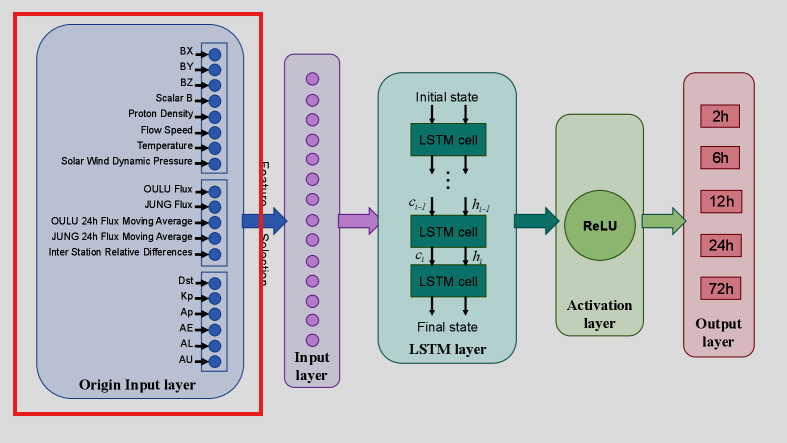

In [31]:
full_dataset.head()

,datetime,Bx_GSE,By_GSM,Bz_GSM,B_Magnitude_Avg,Np_density,V_plasma,T_proton,P_dyn,OULU_flux,JUNG_flux,OULU_MA_24,JUNG_MA_24,Inter_Station_RelDiff,Dst,Kp,ap,AE,AL,AU
0,1995-01-01 00:00:00,-0.6,3.6,-1.2,4.0,16.3,315.0,15816.0,2.87,6371.0,NaN,NaN,NaN,NaN,-2,1.0,4,32,-6,25
1,1995-01-01 01:00:00,-0.9,2.6,-0.7,3.0,18.8,315.0,15601.0,3.28,6356.0,6733.4,6371.000000,NaN,-0.057665,3,1.0,4,38,-11,26
2,1995-01-01 02:00:00,0.5,1.8,0.0,3.2,19.3,320.0,20703.0,3.46,6339.0,6715.3,6363.500000,6733.40,-0.057652,6,1.0,4,34,-12,20
3,1995-01-01 03:00:00,-3.2,2.4,0.7,4.3,16.4,317.0,25094.0,2.90,6355.0,6699.0,6355.333333,6724.35,-0.052704,5,0.0,0,36,-11,24
4,1995-01-01 04:00:00,-4.3,2.1,0.5,4.8,14.5,313.0,25604.0,2.51,6334.0,6736.2,6355.250000,6715.90,-0.061545,3,0.0,0,31,-10,19


### Заполнение пропусков

In [32]:
full_dataset_clean = full_dataset.copy()
full_dataset_clean.isna().sum()

datetime                    0
Bx_GSE                    401
By_GSM                    427
Bz_GSM                    427
B_Magnitude_Avg           401
Np_density               5260
V_plasma                  601
T_proton                 4710
P_dyn                    5268
OULU_flux                 311
JUNG_flux                1588
OULU_MA_24                159
JUNG_MA_24                402
Inter_Station_RelDiff    1899
Dst                         0
Kp                          0
ap                          0
AE                          0
AL                          0
AU                          0
dtype: int64

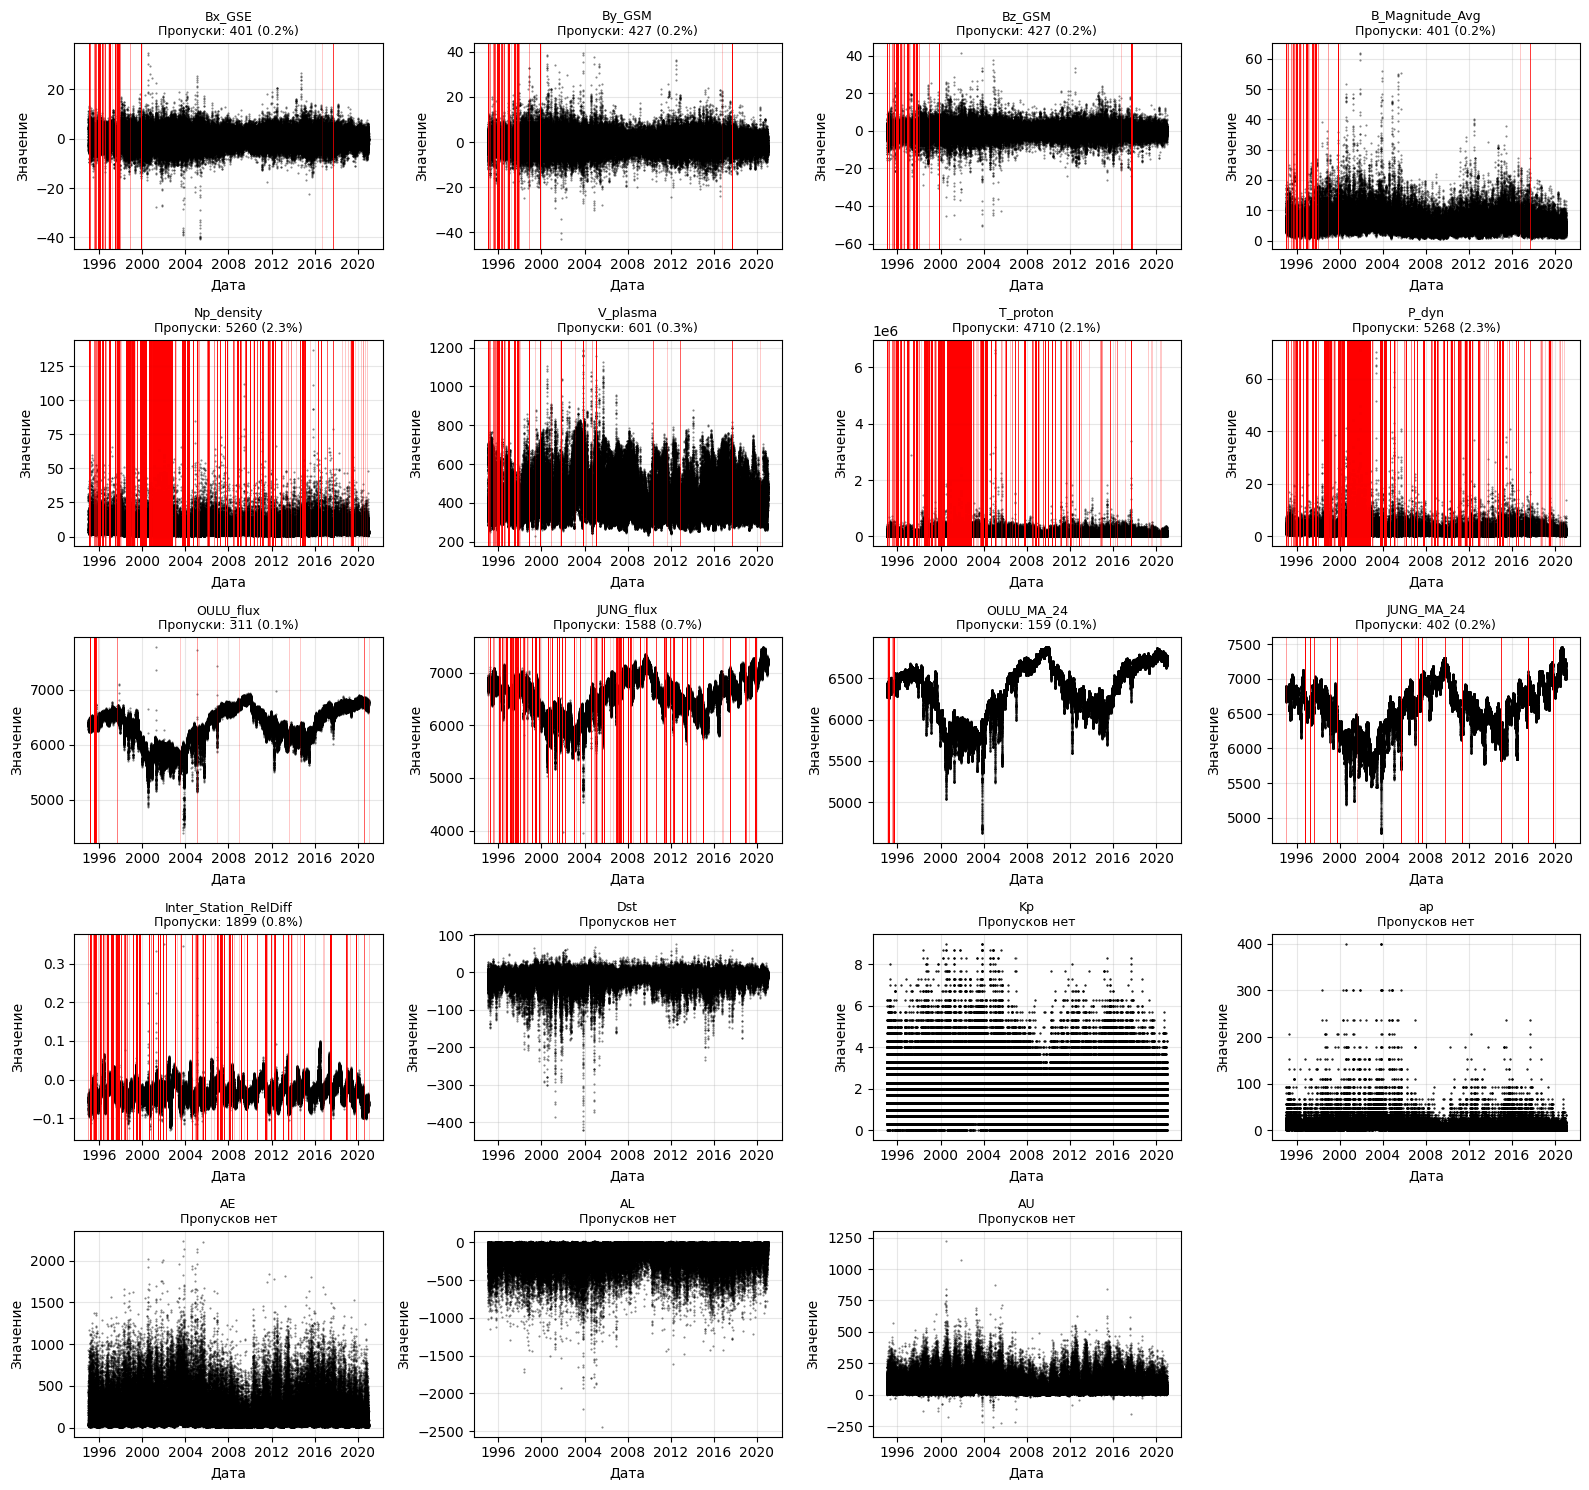

In [33]:
cols_to_plot = [col for col in full_dataset_clean.columns if col != 'datetime']
n_cols = len(cols_to_plot)
n_rows = (n_cols + 3) // 4  

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    
    mask = ~full_dataset_clean[col].isna()
    ax.plot(full_dataset_clean.loc[mask, 'datetime'], full_dataset_clean.loc[mask, col], 
            'k.', markersize=1, alpha=0.5, label='Данные')
    
    nan_count = full_dataset_clean[col].isna().sum()
    if nan_count > 0:
        nan_indices = full_dataset_clean[full_dataset_clean[col].isna()].index
        for nan_idx in nan_indices:
            ax.axvline(x=full_dataset_clean.loc[nan_idx, 'datetime'], 
                       color='r', alpha=0.3, linewidth=0.5)
        title = f'{col}\nПропуски: {nan_count} ({nan_count/len(full_dataset_clean)*100:.1f}%)'
    else:
        title = f'{col}\nПропусков нет'
    
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

for idx in range(len(cols_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
feature_columns = [col for col in full_dataset_clean.columns if col != 'datetime']
for col in feature_columns:
    full_dataset_clean[col] = full_dataset_clean[col].interpolate(
        method='linear', 
        limit=6,           
        limit_direction='both', 
        limit_area='inside'   
    )
full_dataset_clean.isna().sum()

datetime                    0
Bx_GSE                    139
By_GSM                    147
Bz_GSM                    147
B_Magnitude_Avg           139
Np_density               2568
V_plasma                  218
T_proton                 2360
P_dyn                    2568
OULU_flux                 214
JUNG_flux                 732
OULU_MA_24                115
JUNG_MA_24                248
Inter_Station_RelDiff     946
Dst                         0
Kp                          0
ap                          0
AE                          0
AL                          0
AU                          0
dtype: int64

In [35]:
for col in feature_columns:
    full_dataset_clean[col] = full_dataset_clean[col].bfill()

for col in feature_columns:
    full_dataset_clean[col] = full_dataset_clean[col].ffill()

full_dataset_clean.isna().sum()

datetime                 0
Bx_GSE                   0
By_GSM                   0
Bz_GSM                   0
B_Magnitude_Avg          0
Np_density               0
V_plasma                 0
T_proton                 0
P_dyn                    0
OULU_flux                0
JUNG_flux                0
OULU_MA_24               0
JUNG_MA_24               0
Inter_Station_RelDiff    0
Dst                      0
Kp                       0
ap                       0
AE                       0
AL                       0
AU                       0
dtype: int64

### Создание датасета и модели
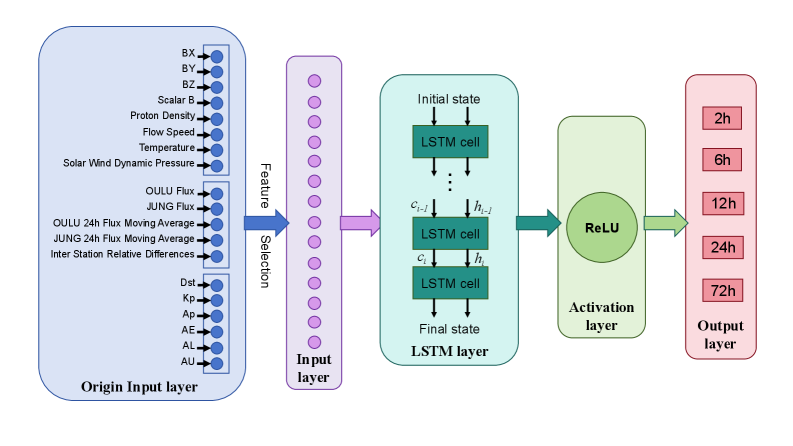

```
Training samples are constructed using a sliding historical window matched to the forecast configuration: each sample is represented by a matrix of size [historical window length × 19]

GCRs propagate at nearly the speed of light... cosmic-ray signatures produced by an approaching CME-driven shock can be observed at Earth well in advance... providing a practical early-warning channel on the order of 1–3 days.
```

In [36]:
class CosmicRayDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        df,                       # DataFrame с 19 колонками (включая Dst)
        X_window_size: int,       # L - размер исторического окна (например, 72)
        horizon: int,             # Δt - на сколько часов вперед прогнозируем (2,6,12,24,48)
        stride: int = 1,
    ):
        self.feature_cols = [col for col in df.columns if col != 'datetime']  
        self.X_data = torch.FloatTensor(df[self.feature_cols].values.copy())
        self.y_data = torch.FloatTensor(df['Dst'].values.copy())
        
        self.X_window_size = X_window_size
        self.horizon = horizon
        self.stride = stride
        
        assert len(self.X_data) == len(self.y_data), "X and y must have same length"
        
        total_required = X_window_size + horizon
        self.num_samples = (len(self.X_data) - total_required) // stride + 1
        assert self.num_samples > 0, f"Not enough data: need {total_required}, have {len(self.X_data)}"
    
    def __len__(self) -> int:
        return self.num_samples
    
    def __getitem__(self, index):
        start_idx = index * self.stride
        
        x_end_idx = start_idx + self.X_window_size
        x_window = self.X_data[start_idx:x_end_idx]  # (X_window_size, 19)
        
        y_idx = x_end_idx + self.horizon - 1
        y_value = self.y_data[y_idx]  # скаляр
        
        return x_window, y_value

*"We conduct experiments for multiple operationally relevant lead times: Δt = 2, 6, 12, 24, and 48 h."*

In [37]:
class CosmicRayModel(nn.Module):
    def __init__(
        self,
        n_features,    
        hidden_size=50, 
        num_layers=1,   
        dropout=0.0
    ) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       
            dropout=dropout if num_layers > 1 else 0
        )
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :] 
        activated = self.act(last_out)
        prediction = self.out(activated)  
        return prediction.squeeze(-1) 

In [38]:
X_WINDOW_SIZE = 72
BATCH_SIZE = 64

###  Обучение на 6 часах

In [39]:
for_train = full_dataset_clean.copy()
for_train = for_train.drop(columns=["datetime"])
n = len(for_train)
train_end = int(n * 0.8)

train_data = for_train.iloc[:train_end]
test_data = for_train.iloc[train_end:]

len(train_data), len(test_data)

(182342, 45586)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
dst_only_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
dst_only_scaler.fit(train_data["Dst"].to_numpy().reshape(-1, 1))
scaled_val = scaler.transform(test_data)

scaled_train_df = pd.DataFrame(scaled_train, index=train_data.index, columns=train_data.columns)
scaled_val_df = pd.DataFrame(scaled_val, index=test_data.index, columns=test_data.columns)

In [ ]:
train_dataset = CosmicRayDataset(df=scaled_train_df, X_window_size=X_WINDOW_SIZE, horizon=6, stride=1)
val_dataset = CosmicRayDataset(df=scaled_val_df, X_window_size=X_WINDOW_SIZE, horizon=6, stride=1)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [43]:
EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

In [ ]:
from tqdm import tqdm

for e in range(EPOCHS):
    model.train()
    train_loss = 0
    train_progress = tqdm(train_loader, desc=f'Epoch {e+1}/{EPOCHS} [Train]')
    for x, y in train_progress:
        optimizer.zero_grad()
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    if val_loss < best_val_loss - PATIENCE_DELTA:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"New best model! val_loss: {best_val_loss:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {e+1}")
            print(f"Best val_loss: {best_val_loss:.6f}")
            break
    
    if (e + 1) % 10 == 0:
        print(f"Epoch {e+1}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}, lr={current_lr:.6f}")

Epoch 1/1000 [Train]: 100%|██████████| 2848/2848 [00:05<00:00, 563.64it/s]


New best model! val_loss: 0.001091


Epoch 2/1000 [Train]: 100%|██████████| 2848/2848 [00:04<00:00, 652.63it/s]


New best model! val_loss: 0.000972


Epoch 3/1000 [Train]: 100%|██████████| 2848/2848 [00:04<00:00, 660.60it/s]


...

New best model! val_loss: 0.000340


Epoch 30/1000 [Train]: 100%|██████████| 2848/2848 [00:04<00:00, 701.54it/s]


Epoch 30: train_loss=0.000453, val_loss=0.000335, lr=0.001000


Epoch 31/1000 [Train]: 100%|██████████| 2848/2848 [00:04<00:00, 700.00it/s]



Early stopping at epoch 31
Best val_loss: 0.000340


In [55]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
model.eval()
predictions = []
targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        pred = model(x).detach().cpu().numpy()
        predictions.extend(pred)
        targets.extend(y.numpy())

predictions = np.array(predictions).flatten()
targets = np.array(targets).flatten()
predictions_nt = dst_only_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
targets_nt = dst_only_scaler.inverse_transform(targets.reshape(-1, 1)).flatten()

In [57]:
rmse_nt = root_mean_squared_error(predictions_nt, targets_nt)
print(f"RMSE (nT): {rmse_nt:.3f}")

RMSE (nT): 9.144


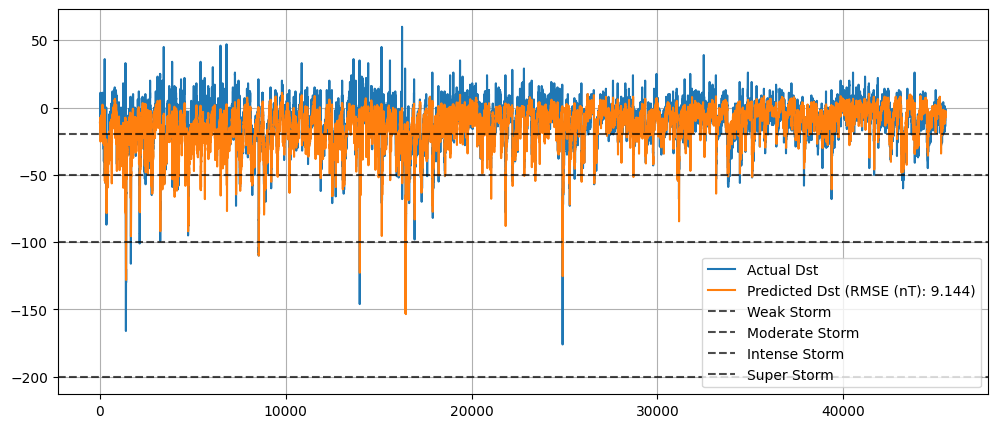

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(targets_nt, label="Actual Dst")
plt.plot(predictions_nt, label=f"Predicted Dst (RMSE (nT): {rmse_nt:.3f})")
plt.axhline(y=-20, color='black', linestyle='--', alpha=0.7, label='Weak Storm')
plt.axhline(y=-50, color='black', linestyle='--', alpha=0.7, label='Moderate Storm')
plt.axhline(y=-100, color='black', linestyle='--', alpha=0.7, label='Intense Storm')
plt.axhline(y=-200, color='black', linestyle='--', alpha=0.7, label='Super Storm')
plt.grid()
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import classification_report

In [ ]:
def labeld_data(dst: np.ndarray) -> np.ndarray:
    labels = np.zeros_like(dst, dtype=np.int64)

    labels[(dst <= -20) & (dst > -50)] = 1  # Weak
    labels[(dst <= -50) & (dst > -100)] = 2 # Moderate
    labels[(dst <= -100) & (dst > -200)] = 3 # Intense
    labels[dst <= -200] = 4 # Super

    return labels


print(classification_report(
    labeld_data(predictions_nt),
    labeld_data(targets_nt),
))

In [ ]:
import copy

def train_cycle(
    data,
    features,
    model,
    loss_fn,
    optimizer,
    scheduler,
    device,
    max_epochs,
    x_window_size,
    horizon,
    batch_size,
    stride,
    test_start_date='2015-01-01',
    patience=10,
    patience_delta=0.0
):
    if isinstance(data.index, pd.DatetimeIndex):
        print("split by datetime")
        train_data = data[data.index < test_start_date]
        test_data = data[data.index >= test_start_date]
    else:
        n = len(data)
        train_end = int(n * 0.8)
        train_data = data.iloc[:train_end]
        test_data = data.iloc[train_end:]

    best_val_rmse = float('inf')
    patience_counter = 0
    best_model_state = None

    scaler = MinMaxScaler(feature_range=(0, 1))
    dst_only_scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_train = scaler.fit_transform(train_data)
    dst_only_scaler.fit(train_data["Dst"].to_numpy().reshape(-1, 1))

    scaled_val = scaler.transform(test_data)

    scaled_train_df = pd.DataFrame(
        scaled_train,
        index=train_data.index,
        columns=train_data.columns
    )
    scaled_val_df = pd.DataFrame(
        scaled_val,
        index=test_data.index,
        columns=test_data.columns
    )
    if features:
        scaled_train_df = scaled_train_df[features]
        scaled_val_df = scaled_val_df[features]


    train_dataset = CosmicRayDataset(
        scaled_train_df,
        x_window_size,
        horizon,
        stride
    )
    val_dataset = CosmicRayDataset(
        scaled_val_df,
        x_window_size,
        horizon,
        stride
    )

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for e in range(max_epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        val_predictions_scaled = []
        val_targets_scaled = []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
                val_loss += loss.item()
                val_predictions_scaled.extend(y_pred.detach().cpu().numpy())
                val_targets_scaled.extend(y.cpu().numpy())

        val_loss /= len(val_loader)
        
        val_predictions_scaled = np.array(val_predictions_scaled).flatten()
        val_targets_scaled = np.array(val_targets_scaled).flatten()
        
        val_predictions_nt = dst_only_scaler.inverse_transform(
            val_predictions_scaled.reshape(-1, 1)
        ).flatten()
        
        val_targets_nt = dst_only_scaler.inverse_transform(
            val_targets_scaled.reshape(-1, 1)
        ).flatten()
        
        val_rmse = np.sqrt(np.mean((val_predictions_nt - val_targets_nt) ** 2))

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        if val_rmse < best_val_rmse - patience_delta:
            best_val_rmse = val_rmse
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"New best model! val_rmse (nT): {best_val_rmse:.3f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {e+1}")
                print(f"Best val_rmse (nT): {best_val_rmse:.3f}")
                break

        if (e + 1) % 10 == 0:
            print(
                f"Epoch {e+1}: "
                f"train_loss={train_loss:.6f}, "
                f"val_loss={val_loss:.6f}, "
                f"val_rmse (nT)={val_rmse:.3f}, "
                f"lr={current_lr:.6f}"
            )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            pred = model(x).detach().cpu().numpy()
            predictions.extend(pred)
            targets.extend(y.numpy())

    predictions = np.array(predictions).flatten()
    targets = np.array(targets).flatten()

    predictions_nt = dst_only_scaler.inverse_transform(
        predictions.reshape(-1, 1)
    ).flatten()

    targets_nt = dst_only_scaler.inverse_transform(
        targets.reshape(-1, 1)
    ).flatten()

    rmse_nt = np.sqrt(np.mean((predictions_nt - targets_nt) ** 2))
    print(f"{horizon=}")
    print(f"RMSE (nT): {rmse_nt:.3f}")

    print("Pointwise classification report:")
    print(
        classification_report(
            labeld_data(targets_nt),
            labeld_data(predictions_nt),
            digits=3
        )
    )

    plt.figure(figsize=(14, 6))
    plt.plot(targets_nt, label="Actual Dst")
    plt.plot(predictions_nt, label=f"Predicted Dst (RMSE (nT): {rmse_nt:.3f})")
    plt.axhline(y=-20, color='black', linestyle='--', alpha=0.7, label='Weak Storm')
    plt.axhline(y=-50, color='black', linestyle='--', alpha=0.7, label='Moderate Storm')
    plt.axhline(y=-100, color='black', linestyle='--', alpha=0.7, label='Intense Storm')
    plt.axhline(y=-200, color='black', linestyle='--', alpha=0.7, label='Super Storm')
    plt.grid()
    plt.legend()
    plt.show()
    # return model, predictions_nt, targets_nt

In [69]:
def event_based_classification(predictions_nt, targets_nt, min_duration=6, overlap_threshold=0.3):
    def get_storm_intervals(dst_series, threshold_min, threshold_max):
        mask = (dst_series <= threshold_min) & (dst_series > threshold_max)
        intervals = []
        start = None
        for i, val in enumerate(mask):
            if val and start is None:
                start = i
            elif not val and start is not None:
                duration = i - start
                if duration >= min_duration:
                    intervals.append((start, i - 1))
                start = None
        if start is not None:
            duration = len(mask) - start
            if duration >= min_duration:
                intervals.append((start, len(mask) - 1))
        return intervals
    
    def compute_overlap(actual_interval, pred_interval):
        start = max(actual_interval[0], pred_interval[0])
        end = min(actual_interval[1], pred_interval[1])
        if end < start:
            return 0.0
        overlap = end - start + 1
        actual_duration = actual_interval[1] - actual_interval[0] + 1
        return overlap / actual_duration
    
    def evaluate_class(actual_intervals, pred_intervals):
        if not actual_intervals:
            return None
        
        matched_actual = set()
        matched_pred = set()
        
        for i_actual, actual in enumerate(actual_intervals):
            best_overlap = 0.0
            best_i_pred = -1
            for i_pred, pred in enumerate(pred_intervals):
                if i_pred in matched_pred:
                    continue
                overlap = compute_overlap(actual, pred)
                if overlap > best_overlap:
                    best_overlap = overlap
                    best_i_pred = i_pred
            
            if best_overlap >= overlap_threshold:
                matched_actual.add(i_actual)
                matched_pred.add(best_i_pred)
        
        tp = len(matched_actual)
        fp = len(pred_intervals) - len(matched_pred)
        fn = len(actual_intervals) - len(matched_actual)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}
    
    thresholds = {
        'Weak': (-30, -50),
        'Moderate': (-50, -100),
        'Intense': (-100, -200),
        'Super': (-200, -float('inf'))
    }
    
    results = {}
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    print("Event-based classification (min_duration={}h, overlap_threshold={}%):".format(min_duration, overlap_threshold*100))
    print("-" * 70)
    print(f"{'Class':<12} {'Actual':<8} {'Predicted':<10} {'TP':<6} {'FP':<6} {'FN':<6} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("-" * 70)
    
    for class_name, (thresh_min, thresh_max) in thresholds.items():
        actual_intervals = get_storm_intervals(targets_nt, thresh_min, thresh_max)
        pred_intervals = get_storm_intervals(predictions_nt, thresh_min, thresh_max)
        
        if not actual_intervals:
            print(f"{class_name:<12} {len(actual_intervals):<8} {len(pred_intervals):<10} {'N/A':<6} {'N/A':<6} {'N/A':<6} {'N/A':<10} {'N/A':<10} {'N/A':<10}")
            continue
        
        metrics = evaluate_class(actual_intervals, pred_intervals)
        
        if metrics:
            results[class_name] = metrics
            print(f"{class_name:<12} {len(actual_intervals):<8} {len(pred_intervals):<10} {metrics['tp']:<6} {metrics['fp']:<6} {metrics['fn']:<6} {metrics['precision']:<10.3f} {metrics['recall']:<10.3f} {metrics['f1']:<10.3f}")
            total_tp += metrics['tp']
            total_fp += metrics['fp']
            total_fn += metrics['fn']
    
    total_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    total_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    total_f1 = 2 * total_precision * total_recall / (total_precision + total_recall) if (total_precision + total_recall) > 0 else 0
    
    print("-" * 70)
    print(f"{'Overall':<12} {'Total':<8} {'Total':<10} {total_tp:<6} {total_fp:<6} {total_fn:<6} {total_precision:<10.3f} {total_recall:<10.3f} {total_f1:<10.3f}")
    
    return results

split by datetime
New best model! val_rmse (nT): 17.091
New best model! val_rmse (nT): 15.677
New best model! val_rmse (nT): 14.811
New best model! val_rmse (nT): 14.476
New best model! val_rmse (nT): 13.316
New best model! val_rmse (nT): 12.331
Epoch 10: train_loss=0.000833, val_loss=0.000737, val_rmse (nT)=13.529, lr=0.001000
New best model! val_rmse (nT): 10.009
New best model! val_rmse (nT): 10.008
New best model! val_rmse (nT): 9.998
Epoch 20: train_loss=0.000690, val_loss=0.000421, val_rmse (nT)=10.231, lr=0.000500
New best model! val_rmse (nT): 9.575
New best model! val_rmse (nT): 9.551
New best model! val_rmse (nT): 9.518
New best model! val_rmse (nT): 9.485
New best model! val_rmse (nT): 9.451
New best model! val_rmse (nT): 9.420
New best model! val_rmse (nT): 9.388
New best model! val_rmse (nT): 9.359
Epoch 30: train_loss=0.000574, val_loss=0.000351, val_rmse (nT)=9.359, lr=0.000250
New best model! val_rmse (nT): 9.329
New best model! val_rmse (nT): 9.302
New best model! val_

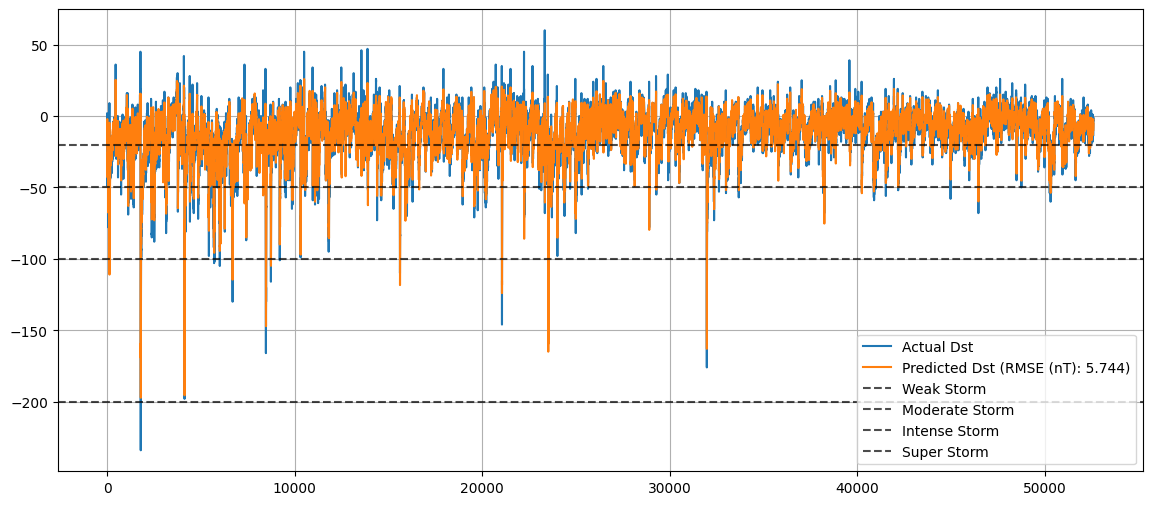

In [ ]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 24
HORIZONS = 2
BATCH_SIZE = 2048

EPOCHS = 1000
PATIENCE = 20
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    features=[],
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 11.109
New best model! val_rmse (nT): 10.847
New best model! val_rmse (nT): 10.497
New best model! val_rmse (nT): 10.151
New best model! val_rmse (nT): 9.648
Epoch 10: train_loss=0.000275, val_loss=0.000374, val_rmse (nT)=9.648, lr=0.001000
New best model! val_rmse (nT): 9.133
New best model! val_rmse (nT): 8.519
New best model! val_rmse (nT): 8.024
New best model! val_rmse (nT): 7.593
New best model! val_rmse (nT): 7.199
New best model! val_rmse (nT): 6.780
New best model! val_rmse (nT): 6.505
New best model! val_rmse (nT): 6.279
New best model! val_rmse (nT): 6.100
New best model! val_rmse (nT): 5.980
Epoch 20: train_loss=0.000193, val_loss=0.000144, val_rmse (nT)=5.980, lr=0.001000
New best model! val_rmse (nT): 5.888
New best model! val_rmse (nT): 5.843
New best model! val_rmse (nT): 5.568
New best model! val_rmse (nT): 5.465
Epoch 30: train_loss=0.000140, val_loss=0.000120, val_rmse (nT)=5.465, lr=0.000500
New best model! val_rmse (

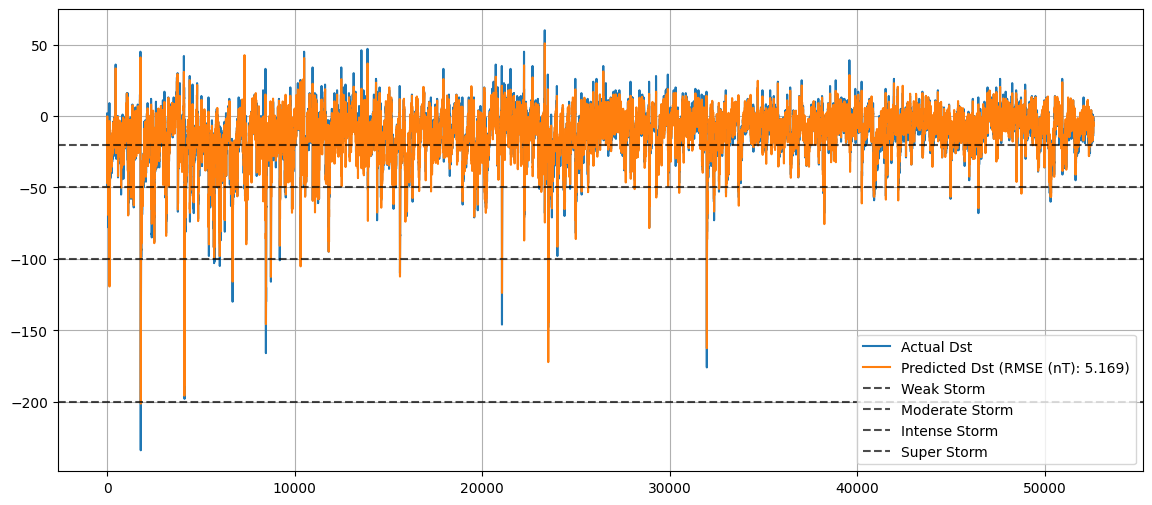

In [92]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 24
HORIZONS = 2
BATCH_SIZE = 32

EPOCHS = 3000
PATIENCE = 20
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 16.953
New best model! val_rmse (nT): 15.810
New best model! val_rmse (nT): 15.015
New best model! val_rmse (nT): 14.684
Epoch 10: train_loss=0.000954, val_loss=0.001072, val_rmse (nT)=16.291, lr=0.000500
New best model! val_rmse (nT): 12.144
New best model! val_rmse (nT): 11.261
New best model! val_rmse (nT): 11.246
New best model! val_rmse (nT): 11.183
Epoch 20: train_loss=0.000793, val_loss=0.000503, val_rmse (nT)=11.183, lr=0.000250
New best model! val_rmse (nT): 11.128
New best model! val_rmse (nT): 11.080
New best model! val_rmse (nT): 11.039
New best model! val_rmse (nT): 11.000
New best model! val_rmse (nT): 10.968
New best model! val_rmse (nT): 10.937
New best model! val_rmse (nT): 10.910
New best model! val_rmse (nT): 10.881
New best model! val_rmse (nT): 10.850
New best model! val_rmse (nT): 10.817
Epoch 30: train_loss=0.000780, val_loss=0.000470, val_rmse (nT)=10.817, lr=0.000250
New best model! val_rmse (nT): 10.778
New best

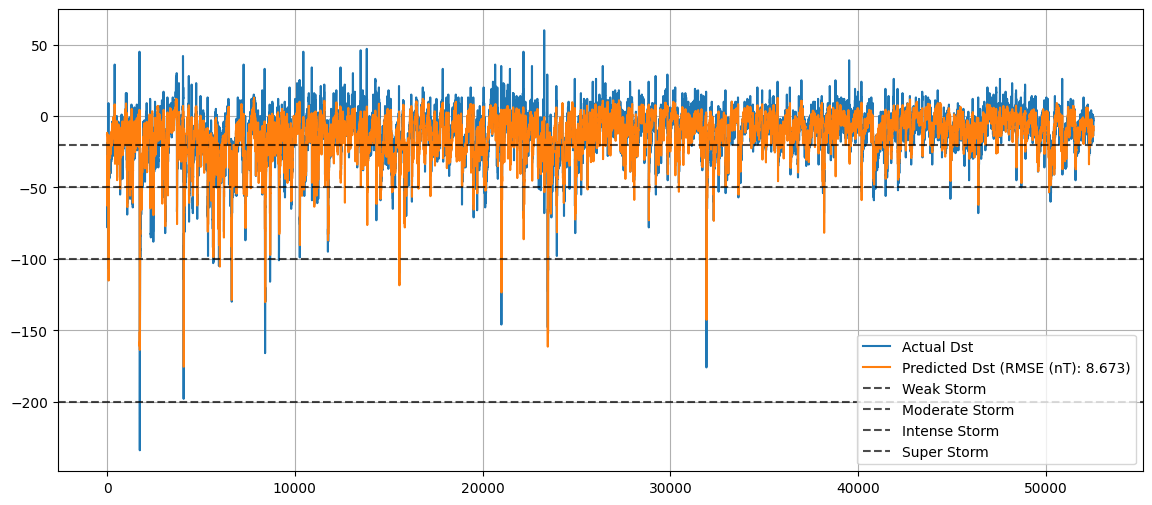

In [ ]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 24
HORIZONS = 6
BATCH_SIZE = 32

EPOCHS = 5000
PATIENCE = 10
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

model_h6, predictions_nt_6, targets_nt_6, = train_cycle(
    data=dataset,
    features=[],
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 18.387
New best model! val_rmse (nT): 16.922
New best model! val_rmse (nT): 15.189
New best model! val_rmse (nT): 14.690
New best model! val_rmse (nT): 14.366
New best model! val_rmse (nT): 14.069
New best model! val_rmse (nT): 13.856
New best model! val_rmse (nT): 13.693
Epoch 10: train_loss=0.001072, val_loss=0.000752, val_rmse (nT)=13.693, lr=0.001000
New best model! val_rmse (nT): 13.583
New best model! val_rmse (nT): 13.497
New best model! val_rmse (nT): 13.441
New best model! val_rmse (nT): 13.399
New best model! val_rmse (nT): 13.368
New best model! val_rmse (nT): 13.341
New best model! val_rmse (nT): 13.319
New best model! val_rmse (nT): 13.297
New best model! val_rmse (nT): 13.277
New best model! val_rmse (nT): 13.254
Epoch 20: train_loss=0.001016, val_loss=0.000704, val_rmse (nT)=13.254, lr=0.001000
New best model! val_rmse (nT): 13.234
New best model! val_rmse (nT): 13.206
New best model! val_rmse (nT): 13.176
New best model! 

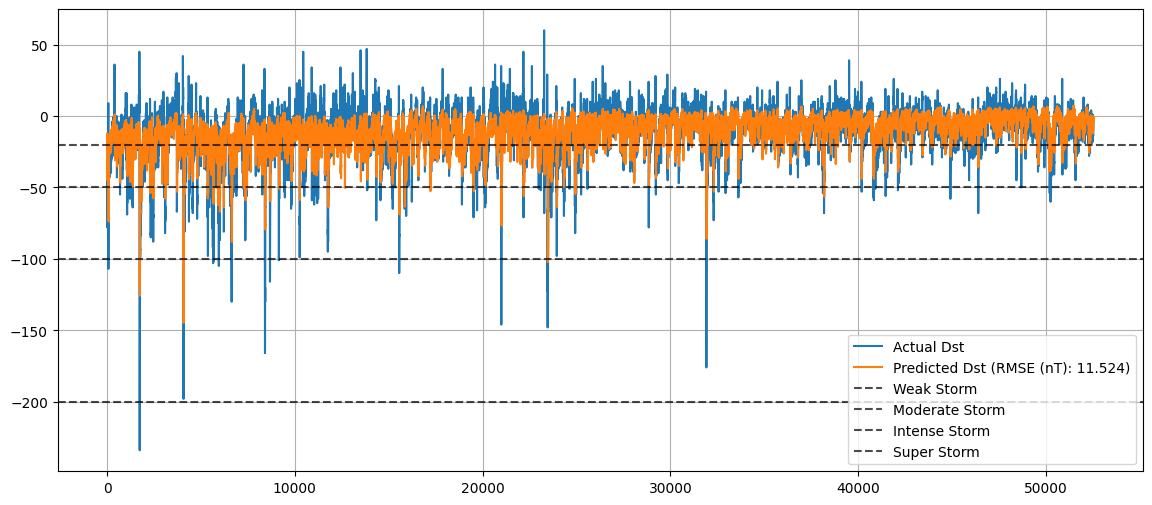

In [ ]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 72
HORIZONS = 12
BATCH_SIZE = 32

EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 17.153
New best model! val_rmse (nT): 16.060
New best model! val_rmse (nT): 16.040
New best model! val_rmse (nT): 14.020
Epoch 10: train_loss=0.001279, val_loss=0.000785, val_rmse (nT)=14.020, lr=0.000500
New best model! val_rmse (nT): 13.556
New best model! val_rmse (nT): 13.547
New best model! val_rmse (nT): 13.533
New best model! val_rmse (nT): 13.521
Epoch 20: train_loss=0.001257, val_loss=0.000729, val_rmse (nT)=13.521, lr=0.000250
New best model! val_rmse (nT): 13.511
New best model! val_rmse (nT): 13.503
New best model! val_rmse (nT): 13.497
New best model! val_rmse (nT): 13.494
New best model! val_rmse (nT): 13.492
Epoch 30: train_loss=0.001256, val_loss=0.000728, val_rmse (nT)=13.510, lr=0.000250
New best model! val_rmse (nT): 13.444
New best model! val_rmse (nT): 13.433
New best model! val_rmse (nT): 13.425
New best model! val_rmse (nT): 13.417
New best model! val_rmse (nT): 13.409
New best model! val_rmse (nT): 13.400
New best

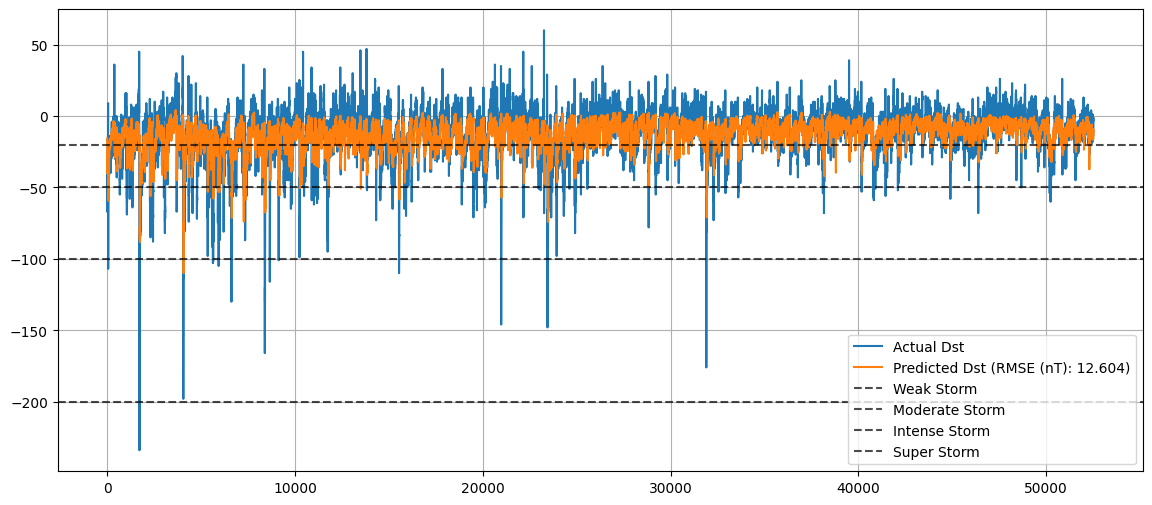

In [ ]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 72
HORIZONS = 24
BATCH_SIZE = 32

EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.00001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 22.438
New best model! val_rmse (nT): 21.425
New best model! val_rmse (nT): 20.903
New best model! val_rmse (nT): 20.518
New best model! val_rmse (nT): 20.243
New best model! val_rmse (nT): 20.020
New best model! val_rmse (nT): 19.829
New best model! val_rmse (nT): 19.650
New best model! val_rmse (nT): 19.488
New best model! val_rmse (nT): 19.347
Epoch 10: train_loss=0.001512, val_loss=0.001503, val_rmse (nT)=19.347, lr=0.001000
New best model! val_rmse (nT): 19.227
New best model! val_rmse (nT): 19.128
New best model! val_rmse (nT): 19.044
New best model! val_rmse (nT): 18.970
New best model! val_rmse (nT): 18.897
New best model! val_rmse (nT): 18.810
New best model! val_rmse (nT): 18.728
New best model! val_rmse (nT): 18.653
New best model! val_rmse (nT): 18.578
New best model! val_rmse (nT): 18.500
Epoch 20: train_loss=0.001497, val_loss=0.001374, val_rmse (nT)=18.500, lr=0.001000
New best model! val_rmse (nT): 18.422
New best model! 

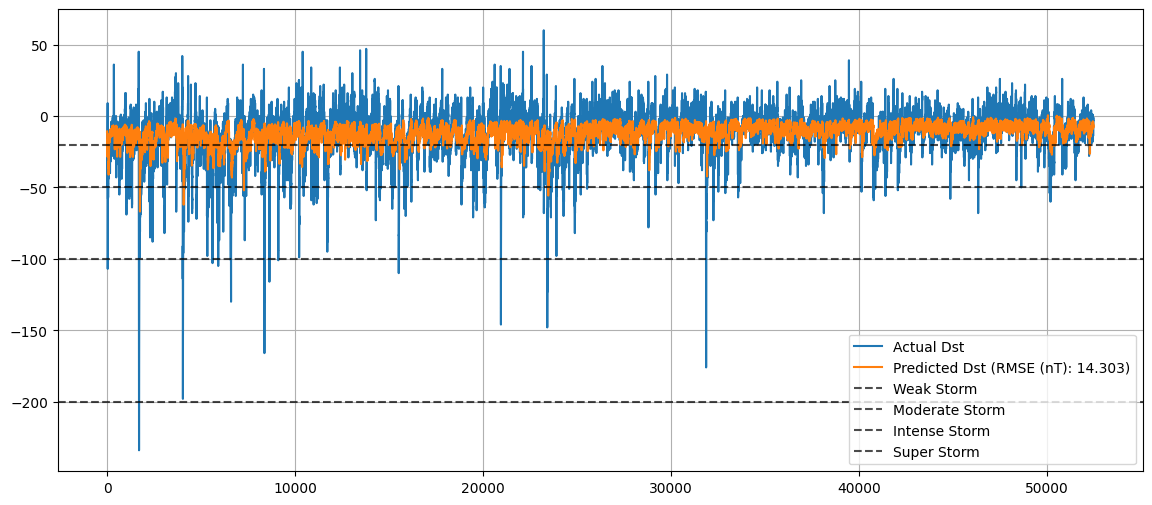

In [95]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 72
HORIZONS = 48
BATCH_SIZE = 32

EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.001
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

asdasd

In [89]:
result = event_based_classification(predictions_nt_6, targets_nt_6, min_duration=6, overlap_threshold=0.3)

Event-based classification (min_duration=6h, overlap_threshold=30.0%):
----------------------------------------------------------------------
Class        Actual   Predicted  TP     FP     FN     Precision  Recall     F1        
----------------------------------------------------------------------
Weak         203      176        99     77     104    0.562      0.488      0.522     
Moderate     59       38         27     11     32     0.711      0.458      0.557     
Intense      9        6          4      2      5      0.667      0.444      0.533     
Super        0        0          N/A    N/A    N/A    N/A        N/A        N/A       
----------------------------------------------------------------------
Overall      Total    Total      130    90     141    0.591      0.480      0.530     


In [50]:
features_without_cr = [
    'Bx_GSE', 'By_GSM', 'Bz_GSM', 'B_Magnitude_Avg', 'Np_density',
    'V_plasma', 'T_proton', 'P_dyn', 'Dst', 'Kp', 'ap', 'AE', 'AL', 'AU'
]

features_with_cr = [
    'Bx_GSE', 'By_GSM', 'Bz_GSM', 'B_Magnitude_Avg', 'Np_density',
    'V_plasma', 'T_proton', 'P_dyn', 'OULU_flux', 'JUNG_flux',
    'OULU_MA_24', 'JUNG_MA_24', 'Inter_Station_RelDiff', 'Dst', 'Kp', 'ap', 'AE', 'AL', 'AU'
]

split by datetime
New best model! val_rmse (nT): 16.602
New best model! val_rmse (nT): 16.060
New best model! val_rmse (nT): 15.893
Epoch 10: train_loss=0.001587, val_loss=0.001256, val_rmse (nT)=17.687, lr=0.000500

Early stopping at epoch 13
Best val_rmse (nT): 15.893
horizon=48
RMSE (nT): 15.893
Pointwise classification report:
              precision    recall  f1-score   support

           0      0.833     0.875     0.854     40605
           1      0.430     0.399     0.414     10590
           2      0.552     0.014     0.027      1170
           3      0.000     0.000     0.000       121
           4      0.000     0.000     0.000         3

    accuracy                          0.758     52489
   macro avg      0.363     0.257     0.259     52489
weighted avg      0.744     0.758     0.744     52489



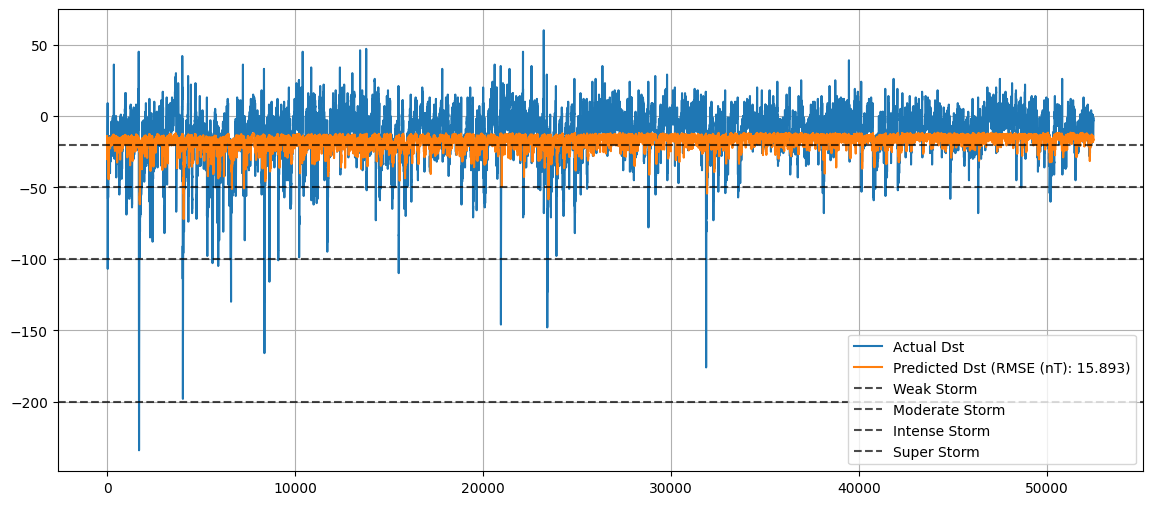

In [182]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 72
HORIZONS = 48
BATCH_SIZE = 128

EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.05
LR = 0.001

model = CosmicRayModel(n_features=14, hidden_size=50, num_layers=1, dropout=0.0)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    features=features_without_cr,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

split by datetime
New best model! val_rmse (nT): 15.117
New best model! val_rmse (nT): 14.552
New best model! val_rmse (nT): 14.494
New best model! val_rmse (nT): 14.490
New best model! val_rmse (nT): 14.484
New best model! val_rmse (nT): 14.483
New best model! val_rmse (nT): 14.471
New best model! val_rmse (nT): 14.453
New best model! val_rmse (nT): 14.445
Epoch 10: train_loss=0.001598, val_loss=0.000835, val_rmse (nT)=14.445, lr=0.001000
New best model! val_rmse (nT): 14.443
Epoch 20: train_loss=0.001506, val_loss=0.001131, val_rmse (nT)=16.802, lr=0.000500

Early stopping at epoch 21
Best val_rmse (nT): 14.443
horizon=48
RMSE (nT): 14.443
Pointwise classification report:
              precision    recall  f1-score   support

           0      0.820     0.949     0.880     40605
           1      0.526     0.271     0.358     10590
           2      0.645     0.017     0.033      1170
           3      0.000     0.000     0.000       121
           4      0.000     0.000     0.000   

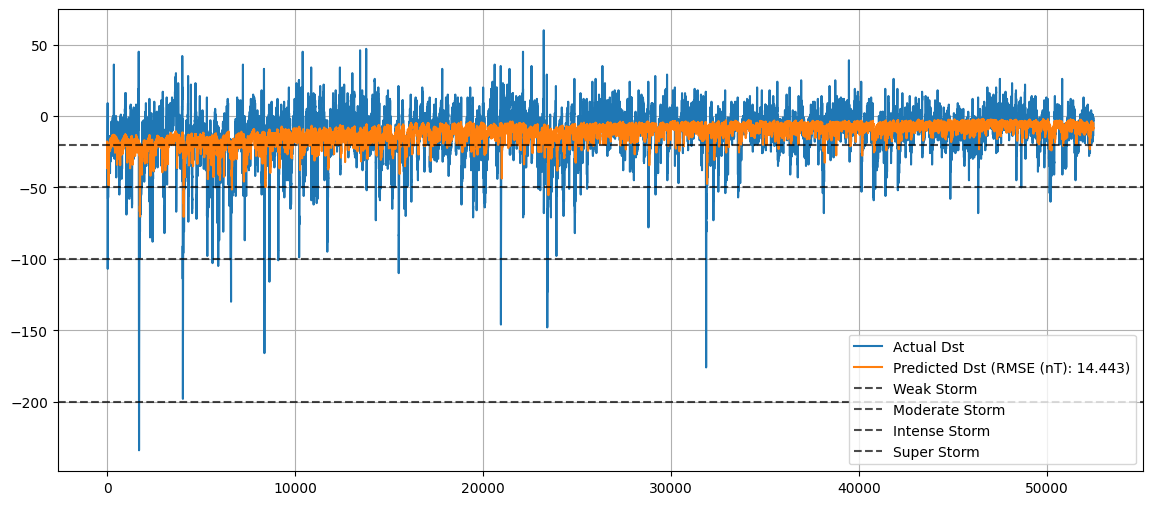

In [51]:
dataset = full_dataset_clean.copy()
dataset = dataset.set_index("datetime")
X_WINDOW_SIZE = 72
HORIZONS = 48
BATCH_SIZE = 512

EPOCHS = 1000
PATIENCE = 10
PATIENCE_DELTA = 0.05
LR = 0.001

model = CosmicRayModel(n_features=19, hidden_size=50, num_layers=1, dropout=0.0)
model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_cycle(
    data=dataset,
    features=features_with_cr,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=EPOCHS,
    x_window_size=X_WINDOW_SIZE,
    horizon=HORIZONS,
    batch_size=BATCH_SIZE,
    stride=1
)

Train size: 182342, Test size: 45586
Baseline RMSE: 11.4518 nT


Computing permutation importance: 100%|██████████| 19/19 [00:18<00:00,  1.03it/s]


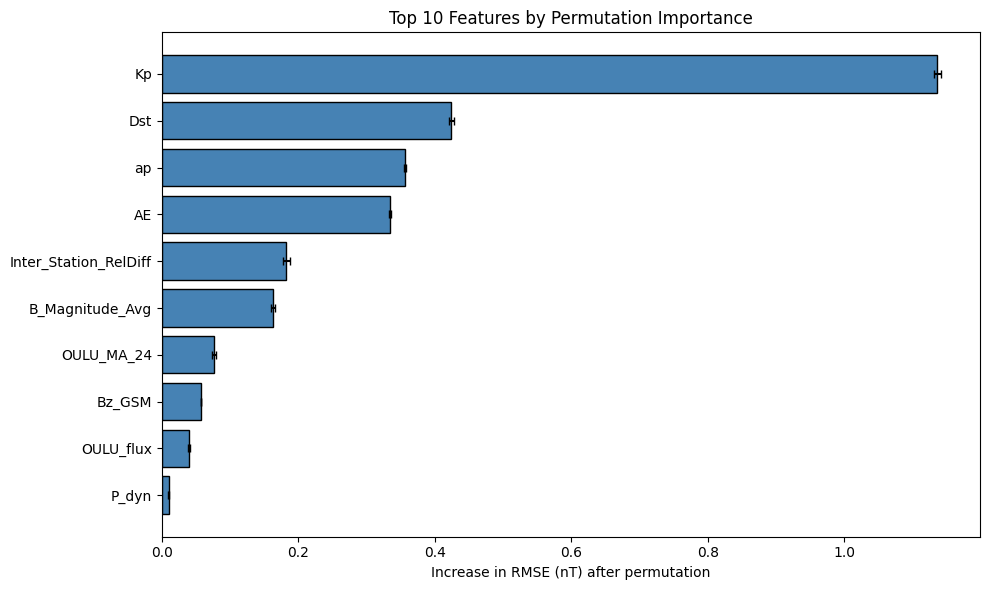

Bx_GSE              : 0.002088 ± 0.001640
By_GSM              : -0.000111 ± 0.000117
Bz_GSM              : 0.057253 ± 0.000444
B_Magnitude_Avg     : 0.162849 ± 0.002790
Np_density          : -0.112706 ± 0.003255
V_plasma            : -0.011554 ± 0.000332
T_proton            : -0.012179 ± 0.000155
P_dyn               : 0.009987 ± 0.000923
OULU_flux           : 0.039497 ± 0.001644
JUNG_flux           : -0.028184 ± 0.001997
OULU_MA_24          : 0.076380 ± 0.002860
JUNG_MA_24          : -0.029831 ± 0.001792
Inter_Station_RelDiff: 0.182511 ± 0.004894
Dst                 : 0.424425 ± 0.003307
Kp                  : 1.136076 ± 0.005483
ap                  : 0.356553 ± 0.001523
AE                  : 0.334024 ± 0.001528
AL                  : -0.003600 ± 0.000705
AU                  : -0.049619 ± 0.000938


In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin


for_train = full_dataset_clean.copy()
for_train = for_train.drop(columns=["datetime"])
n = len(for_train)
train_end = int(n * 0.8)

train_data = for_train.iloc[:train_end]
test_data = for_train.iloc[train_end:]

print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

X_WINDOW_SIZE = 72
BATCH_SIZE = 256

scaler = MinMaxScaler(feature_range=(0, 1))
dst_only_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_data)
dst_only_scaler.fit(train_data["Dst"].to_numpy().reshape(-1, 1))
scaled_test = scaler.transform(test_data)

scaled_train_df = pd.DataFrame(scaled_train, index=train_data.index, columns=train_data.columns)
scaled_test_df = pd.DataFrame(scaled_test, index=test_data.index, columns=test_data.columns)

train_dataset = CosmicRayDataset(df=scaled_train_df, X_window_size=X_WINDOW_SIZE, horizon=6, stride=1)
test_dataset = CosmicRayDataset(df=scaled_test_df, X_window_size=X_WINDOW_SIZE, horizon=6, stride=1)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


class LSTMWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device, scaler_y=None, window_size=72, batch_size=256):
        self.model = model
        self.device = device
        self.scaler_y = scaler_y
        self.window_size = window_size
        self.batch_size = batch_size
    
    def predict(self, X):
        self.model.eval()
        predictions = []
        
        with torch.no_grad():
            for i in range(0, len(X), self.batch_size):
                batch = torch.tensor(X[i:i+self.batch_size], dtype=torch.float32).to(self.device)
                pred = self.model(batch).cpu().numpy()
                predictions.append(pred)
        
        predictions = np.concatenate(predictions, axis=0).flatten()
        
        if self.scaler_y is not None:
            predictions = self.scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
        
        return predictions


def compute_permutation_importance(model, test_loader, device, scaler_y, feature_names, 
                                    window_size=72, n_repeats=5, random_state=42):
    model.eval()
    
    all_X = []
    all_y = []
    
    with torch.no_grad():
        for x, y in test_loader:
            all_X.append(x.cpu().numpy())
            all_y.append(y.cpu().numpy())
    
    X_test = np.concatenate(all_X, axis=0)
    y_test_norm = np.concatenate(all_y, axis=0).flatten()
    
    y_test = scaler_y.inverse_transform(y_test_norm.reshape(-1, 1)).flatten()
    
    wrapper = LSTMWrapper(model, device, scaler_y, window_size)
    
    np.random.seed(random_state)
    
    baseline_pred = wrapper.predict(X_test)
    baseline_rmse = np.sqrt(np.mean((baseline_pred - y_test)**2))
    print(f"Baseline RMSE: {baseline_rmse:.4f} nT")
    
    importances = []
    importances_std = []
    
    for idx, name in enumerate(tqdm(feature_names, desc="Computing permutation importance")):
        scores = []
        
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            X_permuted[:, :, idx] = np.random.permutation(X_permuted[:, :, idx])
            
            pred = wrapper.predict(X_permuted)
            rmse = np.sqrt(np.mean((pred - y_test)**2))
            scores.append(rmse - baseline_rmse)
        
        importances.append(np.mean(scores))
        importances_std.append(np.std(scores))
    
    return np.array(importances), np.array(importances_std)


def plot_permutation_importance(importances, importances_std, feature_names, top_k=10):
    indices = np.argsort(importances)[::-1][:top_k]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_k), importances[indices], xerr=importances_std[indices], 
             capsize=3, color='steelblue', edgecolor='black')
    plt.yticks(range(top_k), [feature_names[i] for i in indices])
    plt.xlabel('Increase in RMSE (nT) after permutation')
    plt.title(f'Top {top_k} Features by Permutation Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


features_with_cr = ['Bx_GSE', 'By_GSM', 'Bz_GSM', 'B_Magnitude_Avg', 'Np_density',
                    'V_plasma', 'T_proton', 'P_dyn', 'OULU_flux', 'JUNG_flux',
                    'OULU_MA_24', 'JUNG_MA_24', 'Inter_Station_RelDiff', 
                    'Dst', 'Kp', 'ap', 'AE', 'AL', 'AU']

importances, importances_std = compute_permutation_importance(
    model=model,
    test_loader=test_loader,
    device=device,
    scaler_y=dst_only_scaler,
    feature_names=features_with_cr,
    window_size=72,
    n_repeats=5
)

plot_permutation_importance(importances, importances_std, features_with_cr, top_k=10)

for name, imp, std in zip(features_with_cr, importances, importances_std):
    print(f"{name:20s}: {imp:.6f} ± {std:.6f}")

<Axes: >

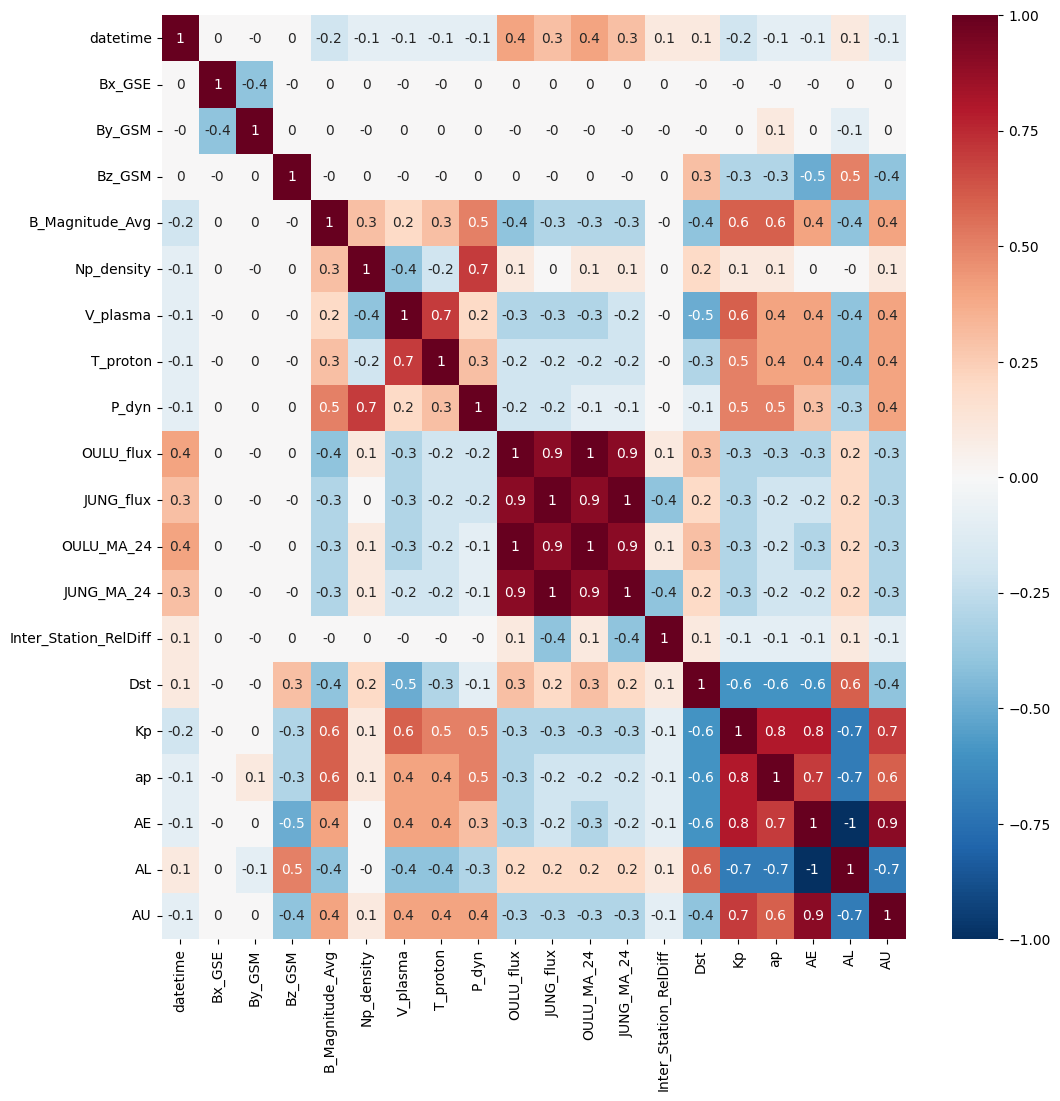

In [66]:
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(full_dataset_clean.corr().round(1), cmap="RdBu_r", annot=True)

Fold 1/5: Train size: 182343, Val size: 45585


RuntimeError: input.size(-1) must be equal to input_size. Expected 16, got 15